In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

FIG_WIDTH = 5
FIG_HEIGHT = 3
TICK_FONTSIZE = 8
AXIS_FONTSIZE = 10
ALIGN_MARGIN = 0.3

sns.set_theme(context='notebook', style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': AXIS_FONTSIZE,
    'xtick.labelsize': TICK_FONTSIZE,
    'ytick.labelsize': TICK_FONTSIZE,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
from pathlib import Path

from hierarchical_ranking.task_level_ranking import (
    calc_paired_tests,
    ranking_from_multiple_paired_tests
)
from hierarchical_ranking.ranking_measures import (
    calc_coverage_per_model,
    get_top_k, 
    L_U_to_CI
)
from hierarchical_ranking.plot_ranks import plot_ranks_intervals
from hierarchical_ranking.conformal_interval_aggregation import merge_intervals_quantile

In [2]:
filename = 'data/mmlu_by_subject.pkl'
data_path = Path(filename)
if not data_path.is_file():
    print(
        f'File not found: {data_path.resolve()}\n\n'
        'Download the MMLU benchmark data first:\n\n'
        'python applications/data/download_data.py mmlu\n\n'
    )
    raise FileNotFoundError(data_path)

In [3]:
with open(data_path, 'rb') as f:
    mmlu_by_subject = pickle.load(f)

all_subjects = list(mmlu_by_subject.keys())
all_models = mmlu_by_subject['abstract_algebra']['model'].unique()
print('Number of models: ', len(all_models))
print('Number of subjects: ', len(all_subjects))

Number of models:  15
Number of subjects:  57


In [4]:
colors = ['rosybrown', 'darkgray', 'salmon', 'chocolate', 'sandybrown',
          'gold', 'goldenrod', 'yellowgreen', 'darkseagreen', 'turquoise',
          'cyan', 'skyblue', 'darkorchid', 'violet', 'hotpink']
model_colors = {
    m: c for m, c in zip(all_models, colors)
}

# Accuracy distribution

## Base values definition

In the PromptEval benchmark, each combination of subject, question, and prompt variant receives a correctness score of either 0 or 1. When defining base values, we clarify which type of uncertainty is being measured. In this example, we average the correctness scores across different prompt variants, resulting in a single accuracy score for each question and subject.

In [5]:
question_base_values = {}
for subject, subject_df in mmlu_by_subject.items():
    question_cols = [c for c in subject_df.columns if str(c).startswith('example_')]
    subject_question_base_values = {}
    for model, g in subject_df.groupby('model', sort=False):
        subject_question_base_values[model] = g[question_cols].mean(axis=0)
    question_base_values[subject] = pd.DataFrame(subject_question_base_values).reset_index(drop=True)

# In question_base_values, there are dataframes with a column for each model and a row for each question.

## Accuracy by model

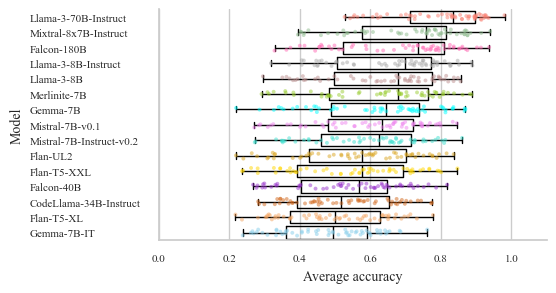

In [6]:
means_by_models = pd.DataFrame({subject: subject_df.mean() for subject, subject_df in question_base_values.items()}).T
models_order_all_subjects = means_by_models.mean().sort_values(ascending=False).index.tolist()
plot_df = means_by_models.reset_index(names='subject').melt(id_vars='subject', 
                                                            var_name='model', 
                                                            value_name='mean_score')

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
sns.boxplot(data=plot_df, y='model', x='mean_score', order=models_order_all_subjects,
            color='black', ax=ax, linewidth=1, fill=False)
sns.stripplot(data=plot_df, y='model', x='mean_score', order=models_order_all_subjects,
              hue='model', palette=model_colors, dodge=False, ax=ax,
              alpha=0.5, size=2.8, jitter=0.2)
ax.set(xlabel='Average accuracy', ylabel='Model')
ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
ax.xaxis.label.set_size(AXIS_FONTSIZE)
ax.yaxis.label.set_size(AXIS_FONTSIZE)
for lbl, model in zip(ax.get_yticklabels(), models_order_all_subjects):
    lbl.set_horizontalalignment('left')
    lbl.set_x(-ALIGN_MARGIN)
ax.set_xlim(0, 1.1);

## Accuracy by subject - examples

In [7]:
subjects_info = {
    'high_school_macroeconomics': {'name': 'High school macroeconomics'}, 
    'abstract_algebra': {'name': 'Abstract algebra'}
}
models_order_two_subjects = means_by_models.loc[subjects_info.keys(),:].mean().sort_values(ascending=False).index.tolist()

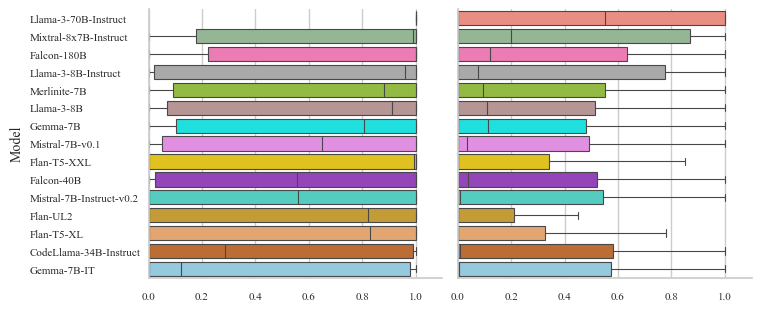

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(1.5 * FIG_WIDTH, FIG_HEIGHT), sharey=True, layout='constrained')
for idx, (ax, subject_name) in enumerate(zip(axs, subjects_info.keys())):
    question_base_long = question_base_values[subject_name].melt(var_name='model', value_name='accuracy')
    sns.boxplot(
        data=question_base_long,
        y='model',
        x='accuracy',
        order=models_order_two_subjects,
        hue='model',
        palette=model_colors,
        dodge=False,
        fliersize=0,
        linewidth=0.8,
        legend=False,
        ax=ax,
    )
    ax.set_xlabel('')
    ax.set_xlim(0, 1.1)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    if idx > 0:
        ax.tick_params(labelleft=False)

axs[0].set_ylabel('Model')
axs[0].yaxis.label.set_size(AXIS_FONTSIZE)
axs[1].set_ylabel('')
for lbl, model in zip(axs[0].get_yticklabels(), models_order_two_subjects):
    lbl.set_horizontalalignment('left')
    lbl.set_x(-1.2 * ALIGN_MARGIN)

# Subject-level rank CIs

In [9]:
alpha_tsk = 0.05
marginal_correction = True
correction_method = 'holm'

In [10]:
all_ranks_intervals = {}
for subject, base_values in question_base_values.items():
    paired_test_res = calc_paired_tests({'data': base_values}, from_summary=False, 
                                         test_func_name='ttest', alternative='less')
    ranks = ranking_from_multiple_paired_tests(paired_test_res, 
                                               alpha=alpha_tsk, 
                                               marginal_correction=marginal_correction,
                                               correction_method=correction_method)
    all_ranks_intervals[subject] = ranks

## Examples

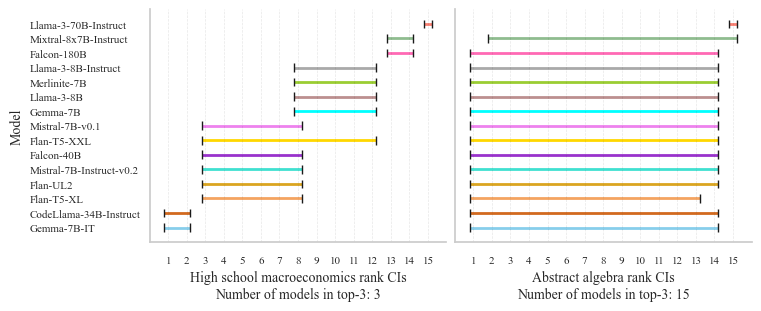

In [11]:
fixed_model_order = models_order_two_subjects[::-1]
fig, axs = plt.subplots(1, 2, figsize=(1.5 * FIG_WIDTH, FIG_HEIGHT), sharey=True, layout='constrained')
for i, s in enumerate(subjects_info.keys()):
    plot_ranks_intervals(
        all_ranks_intervals[s],
        ax=axs[i],
        colors_map=model_colors,
        fixed_order=fixed_model_order,
        align_labels='left',
        align_margin=1.2 * ALIGN_MARGIN,
        labels_fontsize=TICK_FONTSIZE,
        axis_fontsize=AXIS_FONTSIZE,
        show_yticklabels=(i == 0),
    )
    top_3 = get_top_k(all_ranks_intervals[s], 3)
    axs[i].set_ylim(0, len(all_models) + 1)
    axs[i].set_xlabel(
        subjects_info[s]['name'] + ' rank CIs\n'
        + 'Number of models in top-3: ' + str(len(top_3)),
        fontsize=AXIS_FONTSIZE,
    )
axs[1].set_ylabel('');

## Interval-width distribution

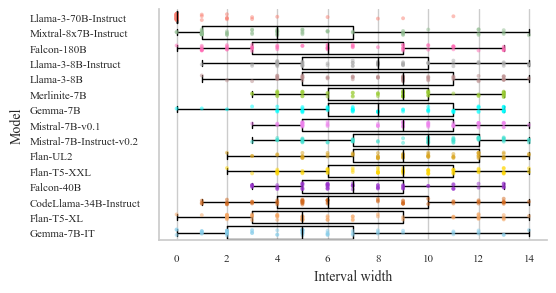

In [12]:
widths_by_model = pd.DataFrame({
    subject: ranks['U'] - ranks['L']
    for subject, ranks in all_ranks_intervals.items()
}).T
plot_df = widths_by_model.reset_index(names='subject').melt(
    id_vars='subject',
    var_name='model',
    value_name='width',
)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
sns.boxplot(data=plot_df, y='model', x='width', order=models_order_all_subjects,
            color='black', ax=ax, linewidth=1, fill=False, fliersize=0)
sns.stripplot(data=plot_df, y='model', x='width', order=models_order_all_subjects,
              hue='model', palette=model_colors, dodge=False, ax=ax,
              alpha=0.5, size=2.8, jitter=0.2, zorder=2)
ax.set(xlabel='Interval width', ylabel='Model')
ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
ax.xaxis.label.set_size(AXIS_FONTSIZE)
ax.yaxis.label.set_size(AXIS_FONTSIZE)
for lbl, model in zip(ax.get_yticklabels(), models_order_all_subjects):
    lbl.set_horizontalalignment('left')
    lbl.set_x(-ALIGN_MARGIN)

# Leaderboard-level rank PIs

## Split subjects

The purpose of rank PIs is to estimate the range of expected ranks for each model on a new task, one that was not used to calculate the PIs, but is drawn from the same distribution as the original tasks.
In this example, we sample 47 subjects out of 57, compute leaderboard rank PIs, and then analyze how well these intervals cover the ranks on the "unseen" tasks that were left out.

In [13]:
seed = 62
np.random.seed(seed)
unseen_subjects = np.random.choice(all_subjects, size=10, replace=False)
print(f'Held-out subjects (n={len(unseen_subjects)}):')
for i, subject in enumerate(unseen_subjects, start=1):
    print(f'  {i:2d}. {subject.replace('_', ' ')}')


Held-out subjects (n=10):
   1. nutrition
   2. high school geography
   3. prehistory
   4. college chemistry
   5. clinical knowledge
   6. security studies
   7. management
   8. international law
   9. human aging
  10. marketing


In [14]:
ldb_subjects = list(set(all_subjects) - set(unseen_subjects))
alpha_ldb = 0.5
ranks_intervals_ldb = pd.concat(
    {k: L_U_to_CI(v) for k, v in all_ranks_intervals.items() if k in ldb_subjects},
    axis=1,
)

## Rank PIs

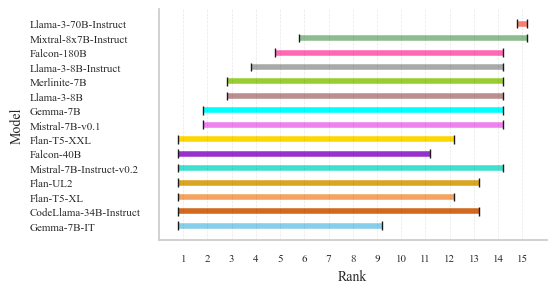

In [15]:
quantile_intervals = merge_intervals_quantile(ranks_intervals_ldb, alpha_ldb=alpha_ldb)
fixed_model_order = models_order_two_subjects[::-1]
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
plot_ranks_intervals(
    quantile_intervals.loc[fixed_model_order],
    ax=ax,
    fixed_order=fixed_model_order,
    colors_map=model_colors,
    labels_fontsize=TICK_FONTSIZE,
    axis_fontsize=AXIS_FONTSIZE,
    align_labels='left',
    align_margin=ALIGN_MARGIN,
    linewidth=4,
);

## Unseen subjects analysis

In [16]:
ranks_intervals_unseen = pd.concat(
    {k: L_U_to_CI(v) for k, v in all_ranks_intervals.items() if k in unseen_subjects},
    axis=1,
)

In [17]:
coverage_per_model_unseen = calc_coverage_per_model(quantile_intervals, ranks_intervals_unseen)
display(coverage_per_model_unseen)


Llama-3-8B                  0.8
Llama-3-8B-Instruct         0.6
Llama-3-70B-Instruct        0.5
CodeLlama-34B-Instruct      1.0
Flan-T5-XL                  0.8
Flan-T5-XXL                 0.5
Flan-UL2                    0.8
Merlinite-7B                0.8
Mixtral-8x7B-Instruct       0.9
Mistral-7B-Instruct-v0.2    0.9
Gemma-7B                    0.6
Gemma-7B-IT                 0.9
Falcon-40B                  0.7
Mistral-7B-v0.1             0.8
Falcon-180B                 0.5
dtype: float64

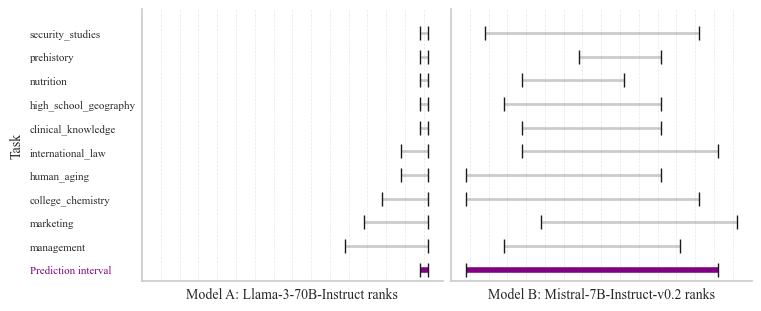

In [18]:
models_info = {
    'Llama-3-70B-Instruct': {'name': 'A'},
    'Mistral-7B-Instruct-v0.2': {'name': 'B'},
}
def task_intervals(model):
    s = ranks_intervals_unseen.loc[model]
    return pd.DataFrame(list(s), index=s.index, columns=['L', 'U'])

ref = task_intervals(next(iter(models_info)))
task_order = (
    ref.assign(_m=(ref['L'] + ref['U']) / 2, _w=ref['U'] - ref['L'])
    .sort_values(['_m', '_w'])
    .index.tolist()
)
fig_paired, axs = plt.subplots(
    1, len(models_info), figsize=(1.5 * FIG_WIDTH, FIG_HEIGHT), sharey=True, layout='constrained',
)
for idx, (model, info) in enumerate(models_info.items()):
    plot_ranks_intervals(
        task_intervals(model),
        ax=np.atleast_1d(axs)[idx],
        fixed_order=task_order,
        ylabel='Task' if idx == 0 else '',
        xlabel=f'Model {info['name']}: {model} ranks',
        max_xtick=len(all_models),
        prediction_interval=quantile_intervals.loc[model, ['L', 'U']].tolist(),
        show_xticklabels=False,
        show_yticklabels=idx == 0,
        show_candidate_yticklabels=True,
        align_labels='left',
        align_margin=1.1 * ALIGN_MARGIN,
        labels_fontsize=TICK_FONTSIZE,
        axis_fontsize=AXIS_FONTSIZE,
    );